### Midterm Project
#### Yiscah Mark
#### nyc-rolling-sales data


##### I opened the file through a google drive link and printed the top few rows so I can examine the data and make changes.

In [1]:
import gdown
import pandas as pd

# The File ID extracted from your link
file_id = '1CgY9jjeGX8ZHSazqIqRBUfHkiNVLW0yj'
url = f'https://drive.google.com/uc?id={file_id}'

# Download the file
# This saves the file as 'midterm_data.csv' in your current folder
output = 'midterm_data.csv'
gdown.download(url, output, quiet=False)

# Open the dataset
df = pd.read_csv(output)

# Verify the requirements (Min 5 columns, 50 rows)
print(f"Dataset Shape: {df.shape}")
df.head()

Downloading...
From: https://drive.google.com/uc?id=1CgY9jjeGX8ZHSazqIqRBUfHkiNVLW0yj
To: /home/1bb32383-9cd3-4863-8b90-d3cb84c7db6b/midterm_data.csv
100%|██████████| 13.6M/13.6M [00:00<00:00, 96.4MB/s]


Dataset Shape: (84548, 22)


,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00


##### I am printing general information about the data set including the data type of each column. There are 22 columns and 84,548 rows of data.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84548 entries, 0 to 84547
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Unnamed: 0                      84548 non-null  int64 
 1   BOROUGH                         84548 non-null  int64 
 2   NEIGHBORHOOD                    84548 non-null  object
 3   BUILDING CLASS CATEGORY         84548 non-null  object
 4   TAX CLASS AT PRESENT            84548 non-null  object
 5   BLOCK                           84548 non-null  int64 
 6   LOT                             84548 non-null  int64 
 7   EASE-MENT                       84548 non-null  object
 8   BUILDING CLASS AT PRESENT       84548 non-null  object
 9   ADDRESS                         84548 non-null  object
 10  APARTMENT NUMBER                84548 non-null  object
 11  ZIP CODE                        84548 non-null  int64 
 12  RESIDENTIAL UNITS               84548 non-null

##### The first thing I wanted to check for is spelling mistakes that often cause overlap of categories. By printing all unique values in each column across the set, I can see if anything is redundant due to a spelling mistake.

In [3]:
for col in df.columns:
    print(f"--- Unique values in '{col}' ---")
    print(df[col].unique())
    print("\n")

--- Unique values in 'Unnamed: 0' ---
[    4     5     6 ... 26737 26738 26739]


--- Unique values in 'BOROUGH' ---
[1 2 3 4 5]


--- Unique values in 'NEIGHBORHOOD' ---
['ALPHABET CITY' 'CHELSEA' 'CHINATOWN' 'CIVIC CENTER' 'CLINTON'
 'EAST VILLAGE' 'FASHION' 'FINANCIAL' 'FLATIRON' 'GRAMERCY'
 'GREENWICH VILLAGE-CENTRAL' 'GREENWICH VILLAGE-WEST' 'HARLEM-CENTRAL'
 'HARLEM-EAST' 'HARLEM-UPPER' 'HARLEM-WEST' 'INWOOD' 'JAVITS CENTER'
 'KIPS BAY' 'LITTLE ITALY' 'LOWER EAST SIDE' 'MANHATTAN VALLEY'
 'MIDTOWN CBD' 'MIDTOWN EAST' 'MIDTOWN WEST' 'MORNINGSIDE HEIGHTS'
 'MURRAY HILL' 'ROOSEVELT ISLAND' 'SOHO' 'SOUTHBRIDGE' 'TRIBECA'
 'UPPER EAST SIDE (59-79)' 'UPPER EAST SIDE (79-96)'
 'UPPER EAST SIDE (96-110)' 'UPPER WEST SIDE (59-79)'
 'UPPER WEST SIDE (79-96)' 'UPPER WEST SIDE (96-116)'
 'WASHINGTON HEIGHTS LOWER' 'WASHINGTON HEIGHTS UPPER' 'BATHGATE'
 'BAYCHESTER' 'BEDFORD PARK/NORWOOD' 'BELMONT' 'BRONX PARK' 'BRONXDALE'
 'CASTLE HILL/UNIONPORT' 'CITY ISLAND' 'CITY ISLAND-PELHAM STRIP'
 'CO

In [4]:
#didn't come up in the null because there is space.

#### #1 The "Ease-ment" column is empty. This was not counted originally in the count of nulls, because there is a space in each cell. With the unique values, this issue came up as the only unique value was a space. In the following cell I remove the entire column from the data set.

In [5]:
import numpy as np

# 1. Drop empty column
df.drop(columns=['EASE-MENT'], inplace=True)

#### #2 Another important change is the date column. As seen in the output of the .info function, the dates are stored as objects. The code bellow makes the dates into real values in time.

In [6]:
# Convert 'SALE DATE' to datetime objects
df['SALE DATE'] = pd.to_datetime(df['SALE DATE'])

# Verify the transformation
print(df['SALE DATE'].dtype)

datetime64[ns]


#### #3 Another change that I made is that an index column is automatically created for the data set. This data set comes already with an index column. The code below drops the index column and uses the column named "unnamed" as the index instead.

In [7]:
# Drop the column (replace 'Unnamed: 0' with the actual name if it has one)
df = df.drop(columns=['Unnamed: 0'])

# Optional: Reset the internal index so it starts at 0
df = df.reset_index(drop=True)


In [8]:
#printing the first few rows to ensure the changes worked.
df.head()

,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,C2,153 AVENUE B,,10009,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19
1,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,C7,234 EAST 4TH STREET,,10009,28,3,31,4616,18690,1900,2,C7,-,2016-12-14
2,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,C7,197 EAST 3RD STREET,,10009,16,1,17,2212,7803,1900,2,C7,-,2016-12-09
3,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,C4,154 EAST 7TH STREET,,10009,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23
4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,C2,301 EAST 10TH STREET,,10009,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17


#### #4 In the unique values I noticed 0 as a value in the "zip code" column, as well as the "year built" column. It is impossible for the values to actually be 0. I changed all the 0 cells to NaN. I took the count to see how often the issue comes up.   

In [9]:
import numpy as np

# Define the columns containing 0 as a placeholder
cols_with_zero = ['ZIP CODE', 'YEAR BUILT']

# Replace 0 with NaN
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

# Verification: Count how many NaNs are now in these columns
print(df[cols_with_zero].isnull().sum())

ZIP CODE       982
YEAR BUILT    6970
dtype: int64


#### #5 Out of the 84,547 rows of data, 982 is only about 1% and it would distort the data very much to make up zip codes. I dropped the columns that were missing zip codes. The "year built" consists of about 8% of the data which is more significant. In order not to loose all the information from these entries I replaced the "NaN" cells with the average year of the rest of the data set. I double checked the count of rows to see if they were dropped.

In [10]:
# 1. Drop rows with missing Zip Codes
df = df.dropna(subset=['ZIP CODE'])

# 2. Fill missing Years with the Median
year_median = df['YEAR BUILT'].median()
df['YEAR BUILT'] = df['YEAR BUILT'].fillna(year_median)

# 3. Final count check
print(f"Final Rows: {df.shape[0]}")
print(f"Final Columns: {df.shape[1]}")

Final Rows: 83566
Final Columns: 20


#### Looking more closely for spelling mistakes. It is likely that any neighborhood that appears very few times is a spelling mistake and not a real neighborhood. I didn't find any mistakes.

In [11]:
# Check for inconsistencies in Neighborhood naming
print(df['NEIGHBORHOOD'].value_counts().tail(20))

NEIGHBORHOOD
NEPONSIT                     34
ARROCHAR-SHORE ACRES         33
LIVINGSTON                   33
CONCORD-FOX HILLS            28
NEW BRIGHTON-ST. GEORGE      27
EMERSON HILL                 20
JAMAICA BAY                  19
FLUSHING MEADOW PARK         16
ROSSVILLE-RICHMOND VALLEY    14
RICHMONDTOWN-LIGHTHS HILL    14
AIRPORT LA GUARDIA            8
BLOOMFIELD                    7
ROSSVILLE-PORT MOBIL          6
CO-OP CITY                    5
DONGAN HILLS-OLD TOWN         5
FRESH KILLS                   2
VAN CORTLANDT PARK            2
BRONX PARK                    1
CITY ISLAND-PELHAM STRIP      1
EAST RIVER                    1
Name: count, dtype: int64


#### #6 The 'LAND SQUARE FEET', 'GROSS SQUARE FEET', and 'SALE PRICE' columns are all numeric values but were stored as objects. I changed the numbers in the column to integers using the .to_numeric function.

In [12]:
# Convert these three to numeric, turning dashes or spaces into NaN
cols_to_fix = ['LAND SQUARE FEET', 'GROSS SQUARE FEET', 'SALE PRICE']

for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col].replace(' -  ', np.nan), errors='coerce')

#### #7 Although the Tax class at the time of sale is a number, it is just a class label with a numeric name. The number doesn't have any real value and I don't want the computer to make calculations with it so I changed it into a string.

In [13]:
# Convert Tax Class from integer to string to reflect it is a category
df['TAX CLASS AT TIME OF SALE'] = df['TAX CLASS AT TIME OF SALE'].astype(str)

# Verify the change
print(df['TAX CLASS AT TIME OF SALE'].dtype)

object


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 83566 entries, 0 to 84547
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   BOROUGH                         83566 non-null  int64         
 1   NEIGHBORHOOD                    83566 non-null  object        
 2   BUILDING CLASS CATEGORY         83566 non-null  object        
 3   TAX CLASS AT PRESENT            83566 non-null  object        
 4   BLOCK                           83566 non-null  int64         
 5   LOT                             83566 non-null  int64         
 6   BUILDING CLASS AT PRESENT       83566 non-null  object        
 7   ADDRESS                         83566 non-null  object        
 8   APARTMENT NUMBER                83566 non-null  object        
 9   ZIP CODE                        83566 non-null  float64       
 10  RESIDENTIAL UNITS               83566 non-null  int64         
 11  COMMERC

In [15]:
# Save the cleaned dataframe to a CSV file
# index=False prevents pandas from creating a new "Unnamed: 0" column
df.to_csv('NYC_Rolling_Sales_Cleaned.csv', index=False)

print("File saved successfully.")

File saved successfully.


#### The dataset I used, "Nyc-rolling-sales data," is a public dataset that was published by the New York City Department of Finance. This is a trustworthy enough source for me to rely on in terms of integrity. I acquired it very ethically, straight from the website. Regarding the ethical considerations of my data, as always, any distortions or changes can distort the truth and increase bias. I will review the changes made to my dataset and discuss the implications. 
#### The first change I made was to remove the "Ease-Ment" column. Every row was missing, so this obviously isn't usable information, and there was no issue with deleting it. A technical change changed the date column from an object to a datetime object. This is so the date can be chronologically ordered and used as intended. Another change to the column's data type was made to improve data accuracy: the tax class number was changed from a numeric value to a string. This is important so the model doesn't make an order or levels in the class and just keeps it as a numeric label. The "Land Square feet", "Gross Square Feet", and "Sale Price" columns were all converted to integers so they can be calculated. 
#### The biggest ethical risk was handling missing values in the "Year Built" and "Zip Code" columns. In the zip code column, I removed those rows because entering new false zip codes would have further distorted the data, and they accounted for only 1% of the data. The issue now is that it is possible there is a pattern or reason the zip code was left out; maybe lower-income households have a harder time keeping accurate records, and removing all those entries makes the class very underrepresented. All empty cells in the year-built column were set to the average year of sale for the other houses in the dataset. This is good because I did not remove the affected entries, so as not to lose the rest of the information. The problem with using the average is that, if the analysis is a time-series model, the middle year would be grossly inaccurate. For a prediction model with the year as just one of the variables, it is okay to set the year to the median so the other variables can be used. Another issue is that most of the houses that are missing a year may have been sold a very long time ago. In that case, the old houses are extremely underrepresented. What I could do to go the extra mile and maintain a very high level of integrity is to document clearly that the year-average was substituted for empty values. As for the zip code, I can cross-reference the block and lot numbers with a secondary city database to find it.
####  Some Legal Guidelines include the Fair Housing Act, which means I can’t use the data for discrimination, and the Privacy Protections rules, which means I have to do more cleaning to remove any identifying information to protect the privacy of the people in the dataset. 


Documentation:
I used gemini to get snippets of code. I wrote all the markdown cells and observations by myself.

# -----------------------FINAL PROJECT - VISUALIZATIONS -------------------------

### Bar chart - sale price per area code
#### I used seaborn to make a bar chart of the average sale price for the 10 most common area codes. The plot was very hard to really get any information from besides for the fact that the zip code of 10167 sold for an average of 2,000,000,000 dollars. The rest of the zipcodes have averages well bellow that, but it is hard to compare them because the bars are so small. It turns out that the area code 10167 is manhattan, where there are very very tall skyscrapers that put the average way out of proportion to the other areas. Since the point was really comparison, I created another bar chart without Manhattan and then I can now see the differences between the price average per area code. The color is to make it exciting; the darker blue is for more expensive and the light yellow is for cheaper proportionally. The color doesn't add any extra information. 

/tmp/ipykernel_1989/2089700361.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_20_zips['ZIP CODE'] = top_20_zips['ZIP CODE'].astype(int).astype(str)
/tmp/ipykernel_1989/2089700361.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


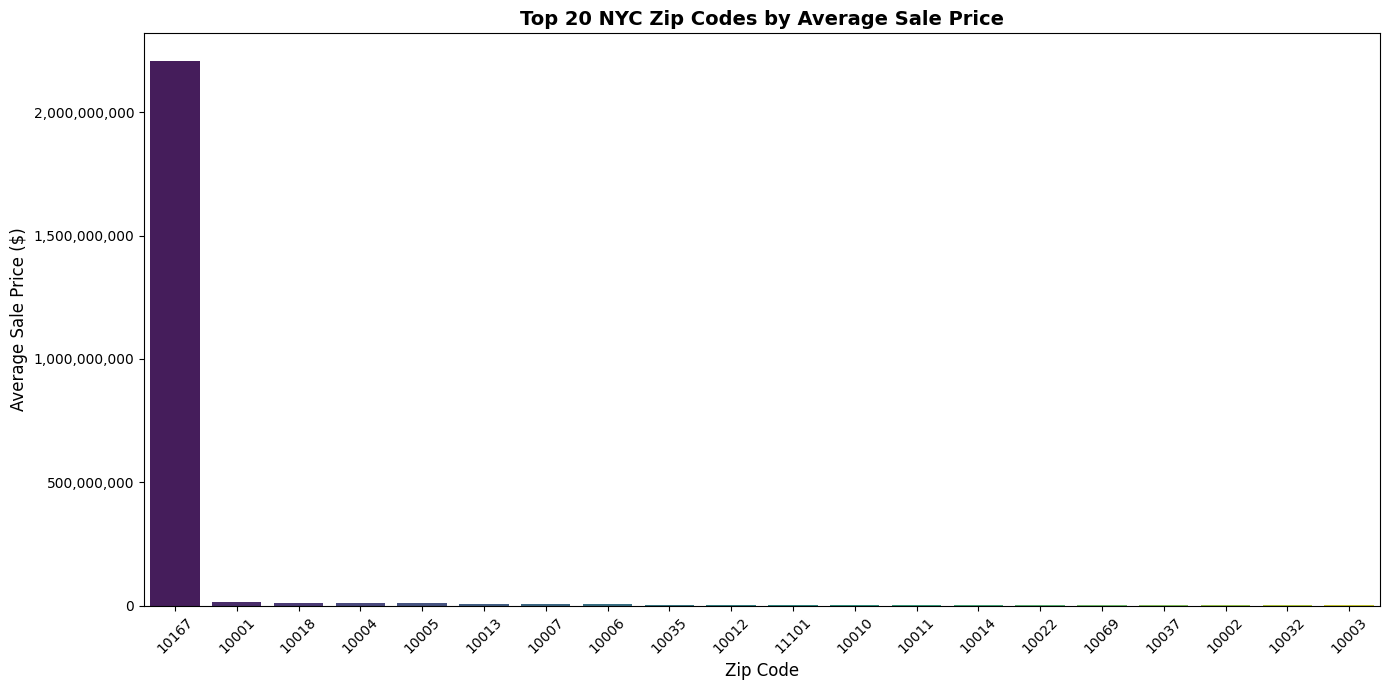

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load your cleaned dataset
# Update the filename/path if necessary
df = pd.read_csv('NYC_Rolling_Sales_Cleaned.csv')

# 2. Group by ZIP Code and calculate the average sale price
# Adjust column names if your cleaned version uses different capitalization (e.g., 'ZIP CODE', 'SALE PRICE')
zip_prices = df.groupby('ZIP CODE')['SALE PRICE'].mean().reset_index()

# 3. Sort descending and select the top 20 for visual clarity
zip_prices = zip_prices.sort_values(by='SALE PRICE', ascending=False)
top_20_zips = zip_prices.head(20)

# Convert ZIP Code to string to ensure discrete categorical plotting
top_20_zips['ZIP CODE'] = top_20_zips['ZIP CODE'].astype(int).astype(str)

# 4. Plot the data
plt.figure(figsize=(14, 7))
sns.barplot(
    x='ZIP CODE', 
    y='SALE PRICE', 
    data=top_20_zips, 
    palette='viridis', 
    hue='ZIP CODE', 
    legend=False
)

# Formatting labels and titles
plt.title('Top 20 NYC Zip Codes by Average Sale Price', fontsize=14, fontweight='bold')
plt.xlabel('Zip Code', fontsize=12)
plt.ylabel('Average Sale Price ($)', fontsize=12)
plt.xticks(rotation=45)

# Format y-axis ticks to display in standard numeric format with commas
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.tight_layout()


/tmp/ipykernel_1989/3496617051.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])


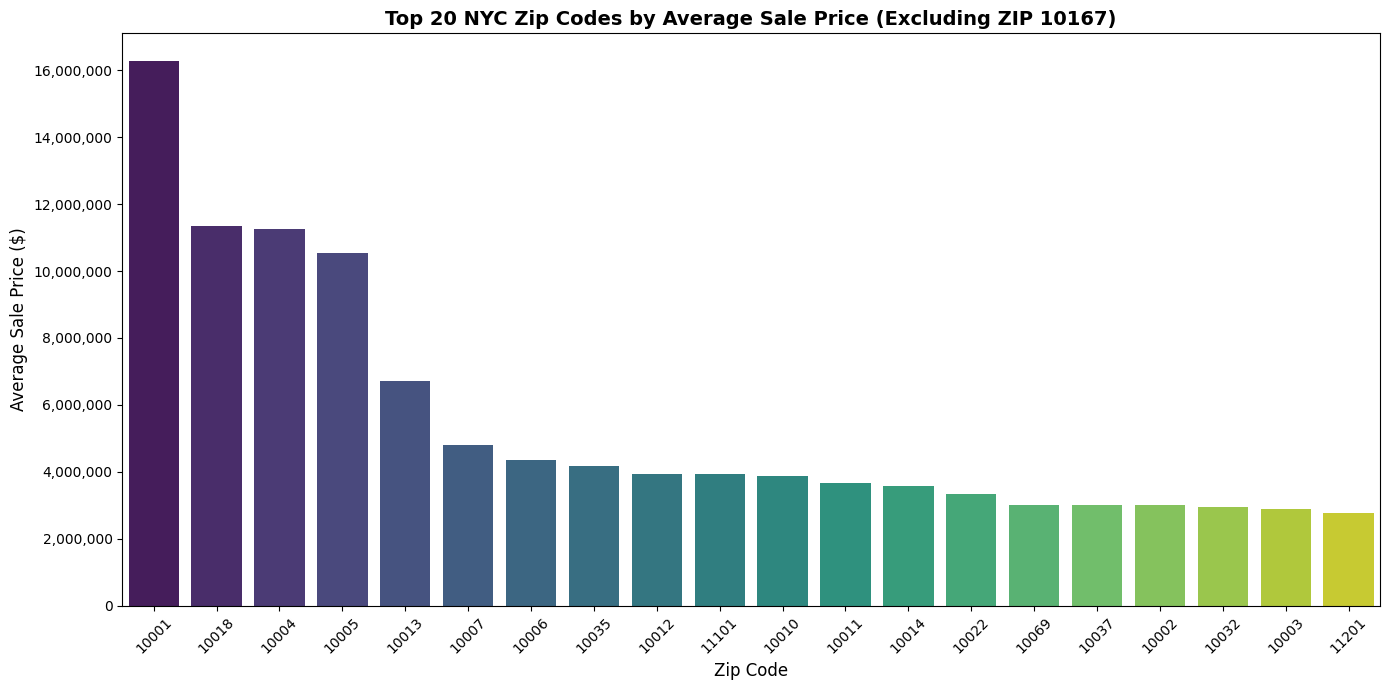

In [7]:
import seaborn as sns

# 1. Load your cleaned dataset
df = pd.read_csv('NYC_Rolling_Sales_Cleaned.csv')


# 2. Group by ZIP CODE and calculate the mean sale price
zip_prices = df.groupby('ZIP CODE')['SALE PRICE'].mean().reset_index()

# 3. Filter out the specific outlier ZIP code (10167)
zip_prices_filtered = zip_prices[zip_prices['ZIP CODE'] != 10167]

# 4. Sort descending and select the top 20 for visual clarity
top_20_zips = zip_prices_filtered.sort_values(by='SALE PRICE', ascending=False).head(20)

# Convert ZIP CODE to string to ensure discrete categorical plotting
top_20_zips['ZIP CODE'] = top_20_zips['ZIP CODE'].astype(int).astype(str)

# 5. Plot the data
plt.figure(figsize=(14, 7))
sns.barplot(
    x='ZIP CODE', 
    y='SALE PRICE', 
    data=top_20_zips, 
    palette='viridis', 
    hue='ZIP CODE', 
    legend=False
)

# Formatting labels and titles
plt.title('Top 20 NYC Zip Codes by Average Sale Price (Excluding ZIP 10167)', fontsize=14, fontweight='bold')
plt.xlabel('Zip Code', fontsize=12)
plt.ylabel('Average Sale Price ($)', fontsize=12)
plt.xticks(rotation=45)

# Format y-axis ticks to display in standard numeric format with commas
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.tight_layout()
plt.show()

### Scatter Plot - Year Built vs. Price
#### I made a scatter plot to compare the sale price to the year the house or building was built. The first time around all the data was centered around the end, starting from the year 1800. I remade the plot so the data is now spread over the entire chart. I used the log scale because I am dealing with such large values. It is fascinating to see the values group at the log points. Overall, I do not see any major correlation between the year a house was built to the selling price. I guess it kind of makes sense, houses don't necessarily lose their value so fast. Also many times old houses are in more expensive sought after locations.

/tmp/ipykernel_1989/606973502.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])


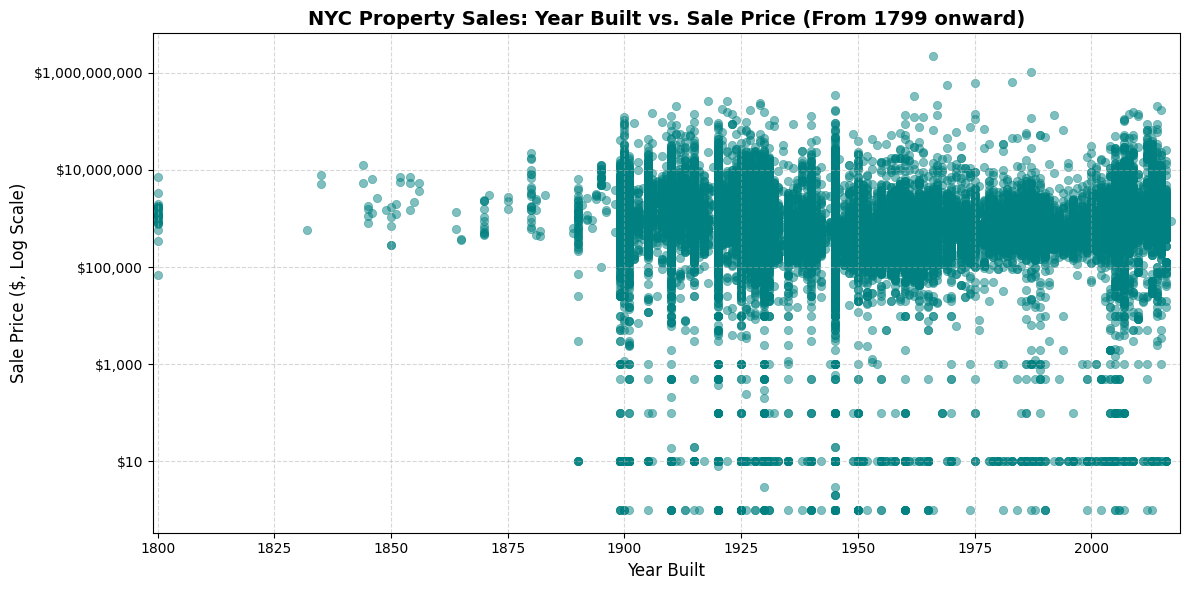

In [9]:
# 2. Filter out any remaining rows where SALE PRICE is 0 or missing
df_filtered = df[df['SALE PRICE'] > 0]

# 3. Plot the data
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='YEAR BUILT', 
    y='SALE PRICE', 
    data=df_filtered, 
    alpha=0.5,          # Adjust transparency to see data density clearly
    color='teal', 
    edgecolor=None
)

# Apply a log scale to the y-axis to handle the massive range in property prices
plt.yscale('log')

# 4. Clean up the X-axis range
# Sets the start precisely at 1799 and dynamically extends to the newest building year
plt.xlim(1799, df_filtered['YEAR BUILT'].max() + 2)

# Formatting labels and titles
plt.title('NYC Property Sales: Year Built vs. Sale Price (From 1799 onward)', fontsize=14, fontweight='bold')
plt.xlabel('Year Built', fontsize=12)
plt.ylabel('Sale Price ($, Log Scale)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Format y-axis ticks to display standard dollar notations instead of scientific notation
current_values = plt.gca().get_yticks()
plt.gca().set_yticklabels(['${:,.0f}'.format(x) for x in current_values])

plt.tight_layout()
plt.show()

### Scatter Plot - Total Units vs. Gross Square Feet
#### I created this plot to confirm common sense, that usually bigger buildings or houses have more units. I wanted to see how strong the correlation is. I used the log scale for both the axis this time because of the large numbers being dealt with. The points are semi transparent so that the each dot is more clear and the don't block each other out. It is hard to see the exact details of the chart, But it is clear that there is a POSITIVE CORRELATION. The more square feet in the property, the more units. 

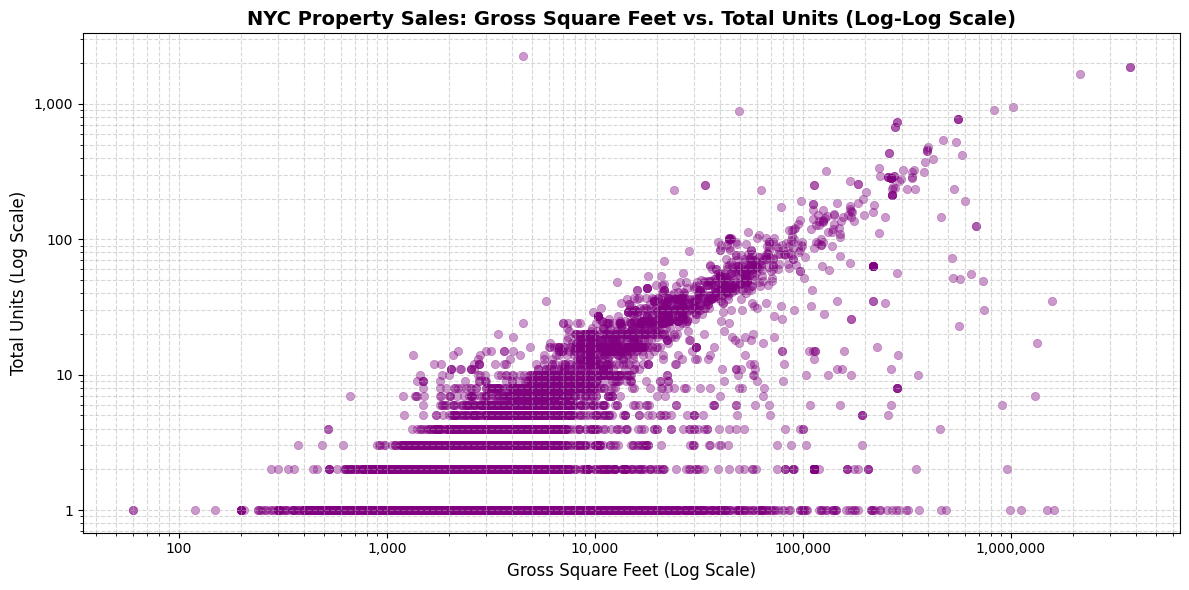

In [10]:
# 2. Filter out rows where either metric is 0 or missing to allow for log transformation
# Log calculations fail for values less than or equal to 0
df_filtered = df[(df['TOTAL UNITS'] > 0) & (df['GROSS SQUARE FEET'] > 0)]

# 3. Plot the data
plt.figure(figsize=(12, 6))
sns.scatterplot(
    x='GROSS SQUARE FEET', 
    y='TOTAL UNITS', 
    data=df_filtered, 
    alpha=0.4,          # High transparency to handle overlapping points
    color='purple', 
    edgecolor=None
)

# Apply log scale to both axes due to the massive variance in building sizes
plt.xscale('log')
plt.yscale('log')

# Formatting labels and titles
plt.title('NYC Property Sales: Gross Square Feet vs. Total Units (Log-Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Gross Square Feet (Log Scale)', fontsize=12)
plt.ylabel('Total Units (Log Scale)', fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Format the axis ticks with commas instead of scientific notation
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

### Pie Chart - Count of Present Tax Class
#### I made this pie to see what the most common tax classes are, and how common each class is. In the first few rows of data there is only 2 different classes, so I used a pie chart to show this. The pie chart has a few large categories and a bunch of crowded categories in the end where it is hard to make out the percentages because they overlap. I debated whether to group the last few categories into one group called other. I made a compromise that although the counts shown aren't exactly 1/2, 1/3, 1/4 or a common fraction as the book mentioned, and that I have too many categories. I will remake the chart with a ledger that states the exact percentage. From the visualization one can tell a basic summary and the ledger shows the exact value. 

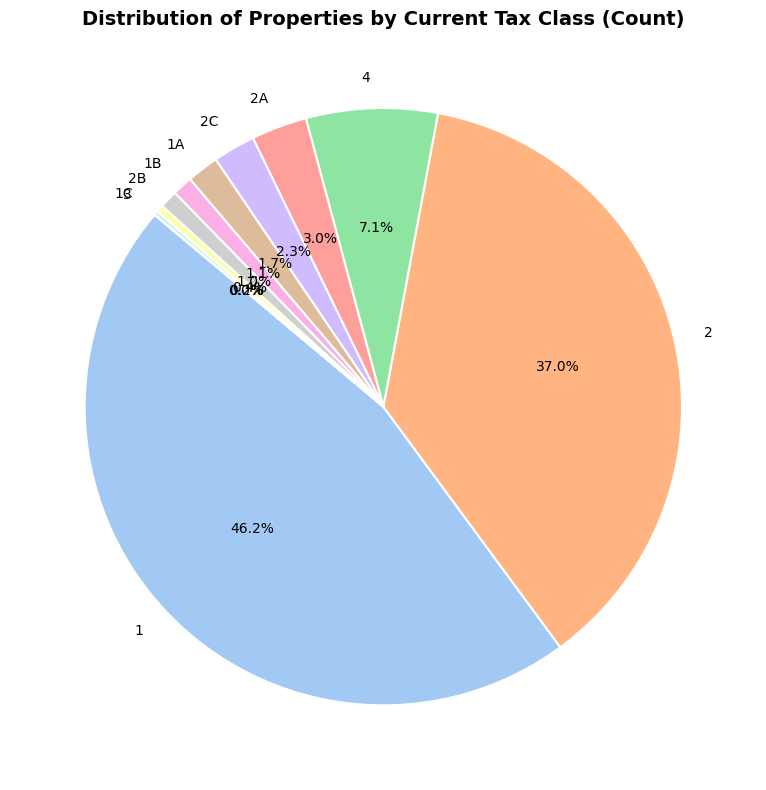

In [11]:
# 2. Get the value counts for the "TAX CLASS AT PRESENT" column
# This handles the aggregation by counting the frequency of each class
tax_class_counts = df['TAX CLASS AT PRESENT'].value_counts()

# 3. Plot the data as a pie chart
plt.figure(figsize=(8, 8))

# Define a clean color palette using seaborn
colors = sns.color_palette('pastel')[0:len(tax_class_counts)]

plt.pie(
    tax_class_counts, 
    labels=tax_class_counts.index, 
    autopct='%1.1f%%',       # Displays percentages on the slices
    startangle=140,          # Rotates the start of the pie for better alignment
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5} # Adds clean borders between slices
)

# Formatting title
plt.title('Distribution of Properties by Current Tax Class (Count)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

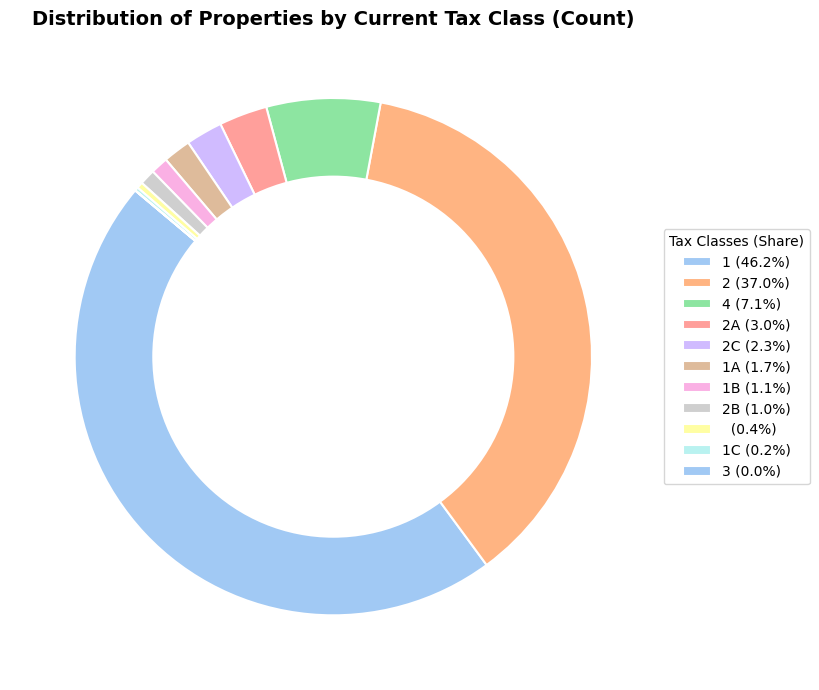

In [14]:
tax_class_counts = df['TAX CLASS AT PRESENT'].value_counts()

# Calculate exact percentages to append to the legend text
percentages = (tax_class_counts / tax_class_counts.sum()) * 100
legend_labels = [f'{label} ({pct:.1f}%)' for label, pct in zip(tax_class_counts.index, percentages)]

plt.figure(figsize=(10, 7))
colors = sns.color_palette('pastel')[0:len(tax_class_counts)]

# Plot without internal percentages (autopct=None)
wedges, _ = plt.pie(
    tax_class_counts, 
    labels=None,            # Disables perimeter labels
    startangle=140,          
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

# Draw a white circle in the center to turn the pie into a donut chart
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add side legend containing both the category label and its exact percentage
plt.legend(
    wedges, 
    legend_labels,
    title="Tax Classes (Share)",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1)
)

plt.title('Distribution of Properties by Current Tax Class (Count)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Histogram - Count per sale price
#### The assignment required a histogram. Since the most important variable in this set is the target variable of price, I made a histogram to show the count of properties sold per price range. I also chose this because price is a numerical value. Since this dataset is so large, I capped the price ate 3,000,000. Now, we can make a lot of observations within that range. It seems like the properties form a bell-shape about 500,000. An interesting observation is that the data is skewed a drop and that with such a large range the oultliers pretty much go in one direction because a house can't sell for less than 0$

/tmp/ipykernel_1989/630126509.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in current_values])


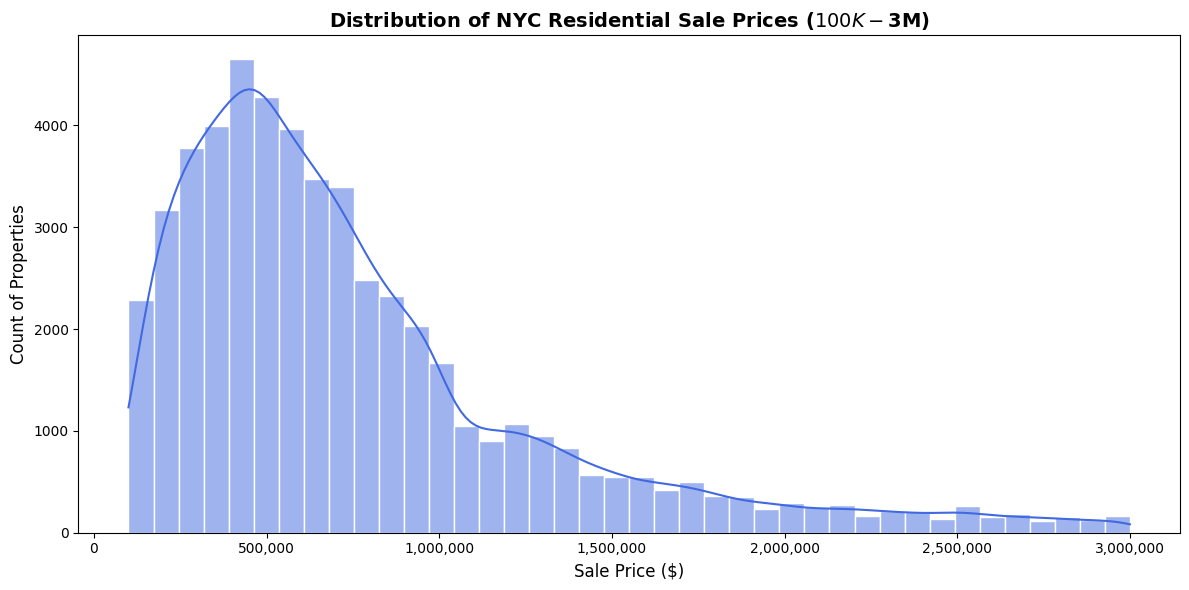

In [15]:
# 2. Filter data for a specific range to keep the histogram readable
# Here we isolate typical residential sales (e.g., $100k to $3M) to avoid outlier skew
market_subset = df[(df['SALE PRICE'] >= 100000) & (df['SALE PRICE'] <= 3000000)]

# 3. Plot the histogram with the KDE curve line
plt.figure(figsize=(12, 6))
sns.histplot(
    data=market_subset, 
    x='SALE PRICE', 
    kde=True,             # Generates the smooth density curve line
    bins=40,              # Adjusts the number of intervals/bars
    color='royalblue', 
    edgecolor='white'
)

# Formatting labels and titles
plt.title('Distribution of NYC Residential Sale Prices ($100K - $3M)', fontsize=14, fontweight='bold')
plt.xlabel('Sale Price ($)', fontsize=12)
plt.ylabel('Count of Properties', fontsize=12)

# Format x-axis ticks with commas for clarity
current_values = plt.gca().get_xticks()
plt.gca().set_xticklabels(['{:,.0f}'.format(x) for x in current_values])

plt.tight_layout()
plt.show()

### -----------WRITEUP--------------

#### Wow! This project was a lot of hard work and fun. Starting all the way at the beginning finding a good dataset to use was not very easy. After searching for quite a long time, I came up with the NYC_Rolling_Sales.csv. This dataset includes a lot of information about different properties sold over NYC. The topic was pretty interesting and relevant so I got started. 

#### This dataset contains many columns and variables so there was a lot of cleaning to do. I checked and fixed the way the values in each column were stored. I then checked for the unique values of each column to spot spelling mistakes and other similar issues. I left out the ID, column so I won't be left with thousands of rows of output. There was a column that was empty so I got rid of it. I looked for empty cells and found some columns where there were zeros that couldn't belong. I the changed the missing or impossible values to NAN so they won't be calculated in numerical calculations. For the zip code column, I just got rid of those entries missing a proper zip code.

#### This week I made visualization, a story form my cleaned data. Each visualization was another observation, some more information to feel around and get to know the data. I see now how important it is to have knowledge about the business case at hand. When There was a very big outlier of a certain zip code by its average price. I was able to figure out how that makes sense. Where that zip code was that its price was so out of range.    

#### Overall, in this course I really enjoyed that hard delving in and cleaning, and searching for meaning in data. I love how there is no one size fits all and each dataset needs new analysis and visualizations to make points.

#### Thank you very much. 